# 🏢 Administradores de Consorcios de CABA — Análisis exploratorio

Análisis de **3.856 administradores de consorcios** registrados en la Ciudad de Buenos Aires
(corte **julio 2026**, verificado contra el endpoint: devuelve el padrón completo, sin paginación
y estable entre requests), a partir de datos públicos del
[buscador oficial del GCBA](https://buscador-admin-consorcio.buenosaires.gob.ar/administradores).

> **Evolución:** este análisis reemplaza al original (corte ~marzo 2024, 5.671 administradores).
> El padrón se achicó un tercio entre ambos cortes y la cifra de consorcios por administrador
> cambió de escala. Todo el histórico queda versionado en `data/snapshots/` y consolidado en
> `data/evolutivo/` — ver sección 8.

> **Privacidad:** este notebook trabaja únicamente con datos **agregados y anonimizados**
> (`data/agregados/`). No se exponen nombres, CUIT ni domicilios. Los agregados se generan con
> `generar_agregados.py` a partir del CSV crudo (local, no versionado).

**Stack:** Python · pandas · matplotlib · seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["font.size"] = 11

DATA = Path("../data/agregados")
IMG = Path("../docs/img")
IMG.mkdir(parents=True, exist_ok=True)

def cargar(nombre):
    return pd.read_csv(DATA / f"{nombre}.csv")

def guardar(fig, nombre):
    fig.savefig(IMG / f"{nombre}.png", bbox_inches="tight", dpi=110)

/tmp/ipykernel_5488/3578584559.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Panorama general (KPIs)

In [2]:
estado = cargar("estado_matricula")
onerosidad = cargar("onerosidad")
sanciones = cargar("sanciones")
concentracion = cargar("concentracion")
distrib = cargar("distribucion_consorcios")

total_admins = int(estado["cantidad"].sum())
total_consorcios = int((distrib["cantidad_consorcios"] * distrib["administradores"]).sum())
pct_activa = estado.set_index("estado").loc["ACTIVA", "cantidad"] / total_admins * 100
pct_oneroso = onerosidad.set_index("oneroso").loc["Sí", "cantidad"] / onerosidad["cantidad"].sum() * 100
pct_sancion = sanciones.set_index("tiene_sanciones").loc["Sí", "cantidad"] / total_admins * 100
sin_consorcios = int(distrib.loc[distrib["cantidad_consorcios"] == 0, "administradores"].iloc[0])

print(f"Administradores registrados : {total_admins:,}")
print(f"Consorcios administrados     : {total_consorcios:,}")
print(f"Matrícula ACTIVA             : {pct_activa:.1f}%")
print(f"Cobran honorarios (oneroso)  : {pct_oneroso:.1f}%")
print(f"Con sanciones                : {pct_sancion:.1f}%")
print(f"Sin ningún consorcio a cargo : {sin_consorcios:,} ({sin_consorcios/total_admins*100:.1f}%)")

Administradores registrados : 3,856
Consorcios administrados     : 1,560
Matrícula ACTIVA             : 27.8%
Cobran honorarios (oneroso)  : 84.4%
Con sanciones                : 1.3%
Sin ningún consorcio a cargo : 2,640 (68.5%)


## 2. Estado de las matrículas

Una matrícula puede estar **activa** o **sin actualizar** (no renovó la DDJJ anual).

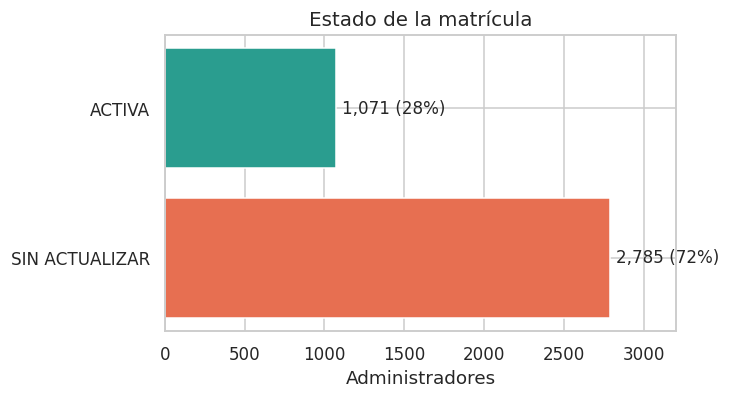

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.5))
colores = {"ACTIVA": "#2a9d8f", "SIN ACTUALIZAR": "#e76f51"}
ax.barh(estado["estado"], estado["cantidad"],
        color=[colores.get(e, "#888") for e in estado["estado"]])
for i, v in enumerate(estado["cantidad"]):
    ax.text(v + 40, i, f"{v:,} ({v/total_admins*100:.0f}%)", va="center")
ax.set_xlabel("Administradores")
ax.set_title("Estado de la matrícula")
ax.margins(x=0.15)
guardar(fig, "estado_matricula")
plt.show()

> 🔎 **Insight:** el **72% de las matrículas están "sin actualizar"** (no renovaron la DDJJ
> anual): solo 1.071 de 3.856 están activas. El padrón vigente es bastante menor al registro,
> incluso después de la depuración observada respecto de 2024 (sección 8).

## 3. Concentración del mercado

¿Cómo se reparten los consorcios entre administradores? Esta es la historia más fuerte del dataset.

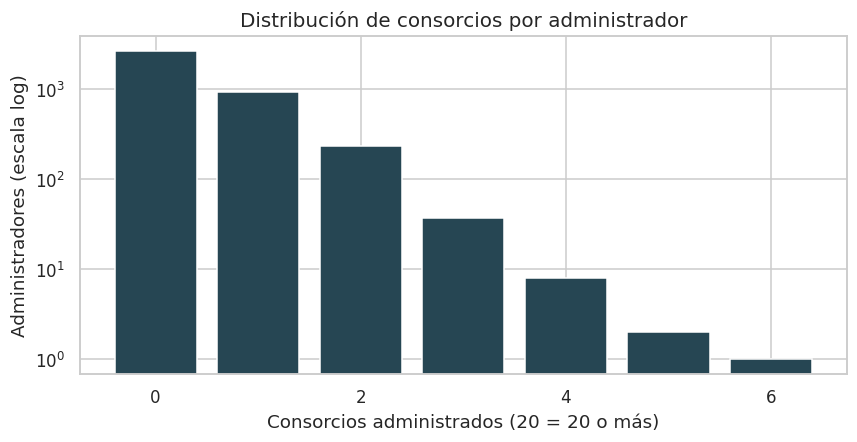

In [4]:
# Distribución (cap a 20 para legibilidad) + cola larga
d = distrib.copy()
d["bucket"] = d["cantidad_consorcios"].clip(upper=20)
agg = d.groupby("bucket")["administradores"].sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(agg.index, agg.values, color="#264653")
ax.set_yscale("log")
ax.set_xlabel("Consorcios administrados (20 = 20 o más)")
ax.set_ylabel("Administradores (escala log)")
ax.set_title("Distribución de consorcios por administrador")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
guardar(fig, "distribucion_consorcios")
plt.show()

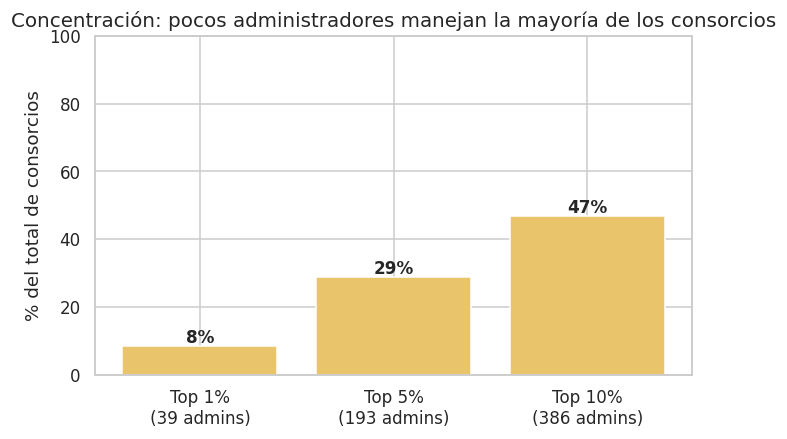

In [5]:
# Curva de concentración tipo Pareto
fig, ax = plt.subplots(figsize=(7, 4))
c = concentracion.dropna(subset=["top_pct"]).copy()
labels = [f"Top {int(p*100)}%\n({n} admins)" for p, n in zip(c["top_pct"], c["top_n_administradores"])]
ax.bar(labels, c["pct_del_total"], color="#e9c46a")
for i, v in enumerate(c["pct_del_total"]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")
ax.set_ylabel("% del total de consorcios")
ax.set_title("Concentración: pocos administradores manejan la mayoría de los consorcios")
ax.set_ylim(0, 100)
guardar(fig, "concentracion")
plt.show()

> 🔎 **Insight:** la concentración es **moderada según el endpoint actual**: el **top 5%**
> (≈193 administradores) maneja el **28,8%** de los consorcios, y nadie supera los **6** a cargo.
> Ojo: en el corte de 2024 el mismo campo mostraba administradores con **más de 100** consorcios
> y el top 5% concentraba el 67%. Un cambio tan drástico sugiere que `CANTIDADCONSORCIOS` cambió
> de semántica (p. ej., solo consorcios con declaración vigente) — ver sección 8.

## 4. Altas de matrículas por año

La fecha de alta nos permite reconstruir la evolución histórica del registro.

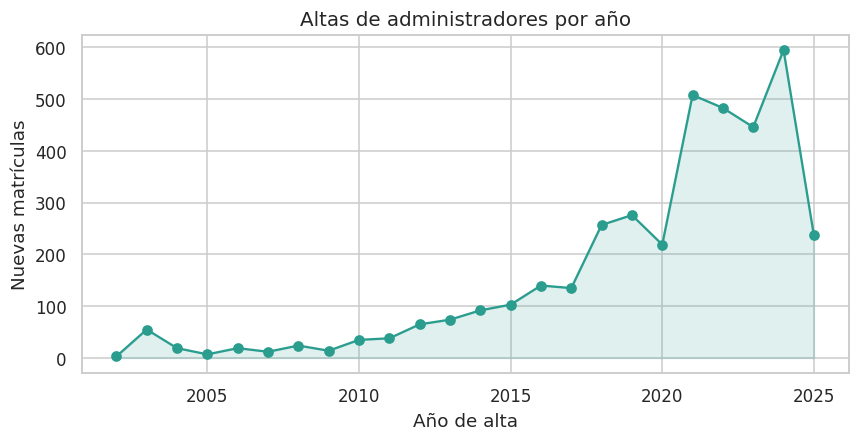

In [6]:
altas = cargar("altas_por_anio")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(altas["anio"], altas["altas"], marker="o", color="#2a9d8f")
ax.fill_between(altas["anio"], altas["altas"], alpha=0.15, color="#2a9d8f")
ax.set_xlabel("Año de alta")
ax.set_ylabel("Nuevas matrículas")
ax.set_title("Altas de administradores por año")
guardar(fig, "altas_por_anio")
plt.show()

> 🔎 **Insight:** las inscripciones se aceleran fuerte desde **2021** y tocan su máximo en
> **2024** (595 altas). 2025 se desacelera (237) y **2026 aún no muestra altas** pese a que el
> padrón registra actualizaciones hasta mayo 2026 — puede reflejar demoras de carga o un freno
> real de nuevas matrículas. Nota: las cohortes viejas están subrepresentadas porque este corte
> ya no incluye a quienes salieron del padrón (sesgo de supervivencia).

## 5. Onerosidad, sanciones y tipo de persona

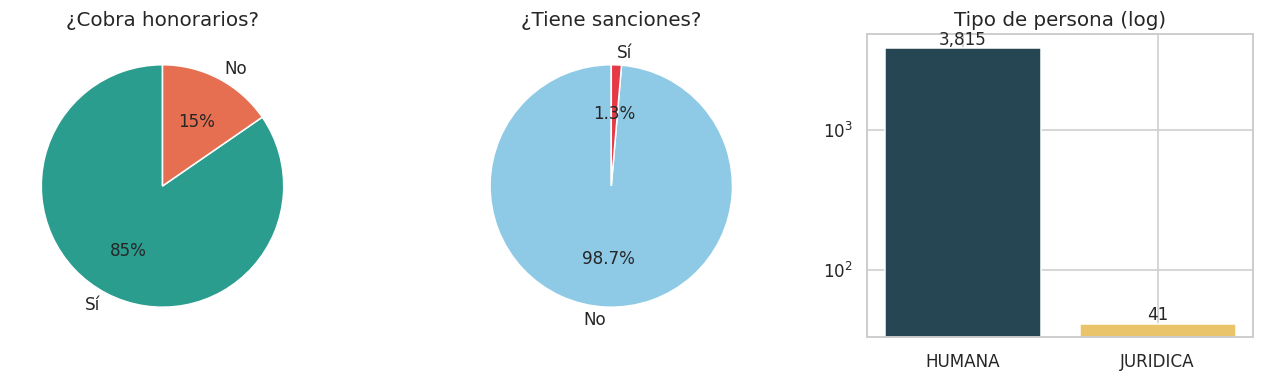

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

o = onerosidad.dropna(subset=["oneroso"])
axes[0].pie(o["cantidad"], labels=o["oneroso"], autopct="%1.0f%%",
            colors=["#2a9d8f", "#e76f51"], startangle=90)
axes[0].set_title("¿Cobra honorarios?")

s = sanciones
axes[1].pie(s["cantidad"], labels=s["tiene_sanciones"], autopct="%1.1f%%",
            colors=["#8ecae6", "#e63946"], startangle=90)
axes[1].set_title("¿Tiene sanciones?")

tp = cargar("tipo_persona")
axes[2].bar(tp["tipo_persona"], tp["cantidad"], color=["#264653", "#e9c46a"])
axes[2].set_yscale("log")
axes[2].set_title("Tipo de persona (log)")
for i, v in enumerate(tp["cantidad"]):
    axes[2].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
guardar(fig, "perfil")
plt.show()

> 🔎 **Insight:** ~**85% cobra honorarios**, solo **1,3% registra sanciones**, y la actividad
> es casi totalmente de **personas humanas** (las sociedades son ~1%).

## 6. Estimación de género (por prefijo de CUIT)

Convención AFIP: CUIT que empieza en 20/23/24 ≈ masculino, 27 ≈ femenino. Es una **estimación
agregada** — no se expone ningún CUIT individual.

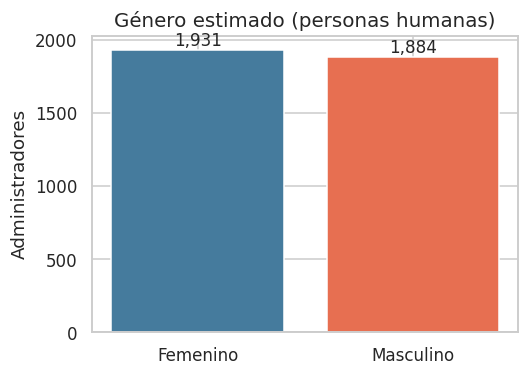

In [8]:
g = cargar("genero_estimado")
g = g[g["genero_estimado"] != "Indeterminado"]
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(g["genero_estimado"], g["cantidad"], color=["#457b9d", "#e76f51"])
for i, v in enumerate(g["cantidad"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_ylabel("Administradores")
ax.set_title("Género estimado (personas humanas)")
guardar(fig, "genero_estimado")
plt.show()

> 🔎 **Insight:** la actividad está **equilibrada por género**, con una leve mayoría femenina
> (~50,6% / 49,4%) — en el corte de 2024 la mayoría era masculina. Algo poco común en otros
> registros profesionales.

## 7. Conclusiones

- **Padrón depurado pero aún inflado:** 72% de las matrículas sin actualizar y ~68% no
  administra ningún consorcio.
- **Concentración moderada** según el endpoint actual (top 5% ≈ 28,8%), pero con un cambio de
  semántica pendiente de confirmar respecto del corte 2024.
- **El boom de inscripciones se mudó:** de 2018–2019 (corte 2024) a **2021–2024**, con freno
  en 2025 y sin altas registradas en 2026.
- **Bajo nivel de sanciones** (1,3%), mayoría de **personas humanas** que **cobran honorarios**,
  y **leve mayoría femenina**.

---
*Datos públicos del GCBA, agregados y anonimizados. Análisis con fines educativos.*

## 8. Evolución del padrón

El repo versiona un snapshot mensual del padrón en `data/snapshots/YYYY-MM/` y los consolida en
`data/evolutivo/`. Entre el corte del análisis original (**~marzo 2024**, fecha estimada por la
distribución de altas: la cohorte 2024 estaba ~19% completa) y este corte (**julio 2026**):

| Métrica | ~2024-03 | 2026-07 |
|---|---:|---:|
| Administradores | 5.671 | 3.856 |
| Consorcios informados | 7.744 | 1.560 |
| Top 5% concentra | 67,4% | 28,8% |

La caída del padrón se concentra en las cohortes 2010–2020 (−50/65%), consistente con una
**depuración gradual por falta de renovación**; el cambio de escala en consorcios apunta a un
**cambio de semántica del endpoint**. Ambas lecturas quedan documentadas en los `metadata.json`
de cada snapshot y en el reporte mensual.

In [9]:
evolutivo = pd.read_csv("../data/evolutivo/resumen.csv")
cols = ["snapshot", "total_administradores", "total_consorcios", "matriculas_activas",
        "pct_top_5", "gini", "sancionados"]
evolutivo[cols]

,snapshot,total_administradores,total_consorcios,matriculas_activas,pct_top_5,gini,sancionados
0,2024-03,5671,7744,2184,67.4,0.8815,106
1,2026-07,3856,1560,1071,28.8,0.7407,52
